# Brownian Bridge

A **Brownian bridge** is Brownian motion that already knows where it has to end up. Ordinary Brownian motion starts at 0 and wanders off wherever it likes. A bridge is tied down at *both* ends: it starts at `initial_value` and must arrive at `final_value` at time `end_time`. In between it wanders freely, but it always lands on target.

Because both ends are fixed, the path has no room to move at the very start or the very finish, and the most room in the middle. It turns up whenever the end of a random path is already known -- the standard example in a statistics course is the Kolmogorov-Smirnov statistic, which measures the gap between a sample's ECDF and the true CDF. That gap is 0 at both ends by construction, so it behaves like a bridge.

Each draw is a sample path -- a function of continuous time giving the value at each moment.

In [1]:
from symbulate import *

## Create a process and draw a path

The default is the *standard* Brownian bridge: from 0 at time 0 to 0 at time 1. Notice the first and last values are exactly 0, while the ones in between are random.

In [2]:
X = BrownianBridge(end_time=1)
path = X.draw()
[round(float(path(t)), 2) for t in [0, 0.25, 0.5, 0.75, 1]]

[0.0, -0.06, 0.4, -0.12, 0.0]

## Simulate and plot sample paths

Every path is squeezed to a point at both ends and fans out in between. The widest spread is halfway across.

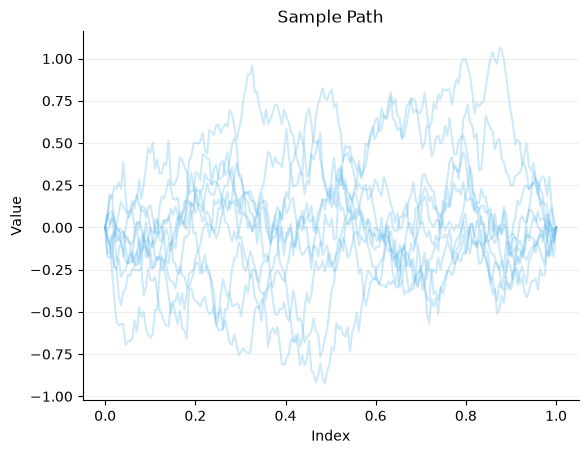

In [3]:
X.sim(10).plot(tmin=0, tmax=1)

## Compare with Brownian motion

This is the same picture with the far end untied. Brownian motion starts at 0 too, but nothing brings it back, so the paths keep spreading out and end up all over the place at time 1.

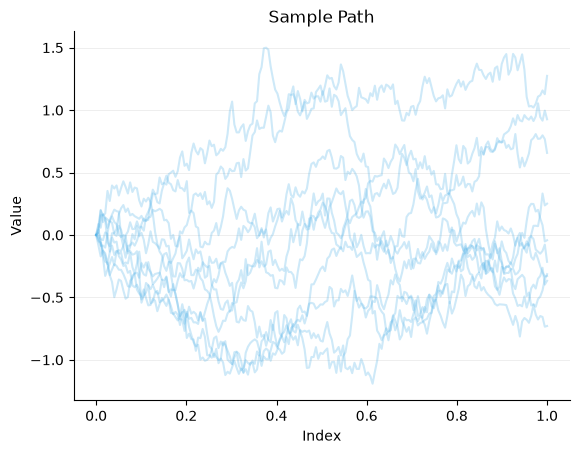

In [4]:
BrownianMotion(scale=1).sim(10).plot(tmin=0, tmax=1)

## Tie the ends down somewhere else

`initial_value` and `final_value` set the two ends, and `end_time` says when the bridge finishes. Here it runs from 2 up to 10 over 4 units of time. Both ends are exact on every draw.

In [5]:
Y = BrownianBridge(end_time=4, initial_value=2, final_value=10)
path = Y.draw()
float(path(0)), float(path(4))

(2.0, 10.0)

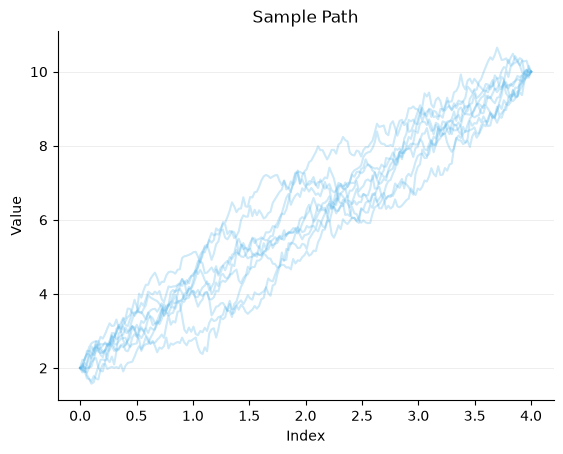

In [6]:
Y.sim(10).plot(tmin=0, tmax=4)

## How much it wanders

`scale` controls how far the path strays from the straight line between the two ends. A bigger `scale` gives a wider bulge in the middle, but the two ends stay pinned no matter what.

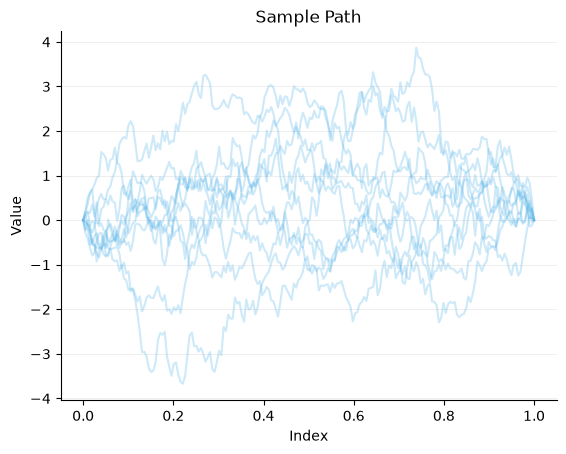

In [7]:
BrownianBridge(end_time=1, scale=3).sim(10).plot(tmin=0, tmax=1)

## The value at a fixed time

The value at a particular time is itself a random variable. Index the process at a time, `X[t]`, to get it. For the standard bridge the spread at time `t` is `t * (1 - t)`, so at the midpoint it is `0.5 * 0.5` = 0.25.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


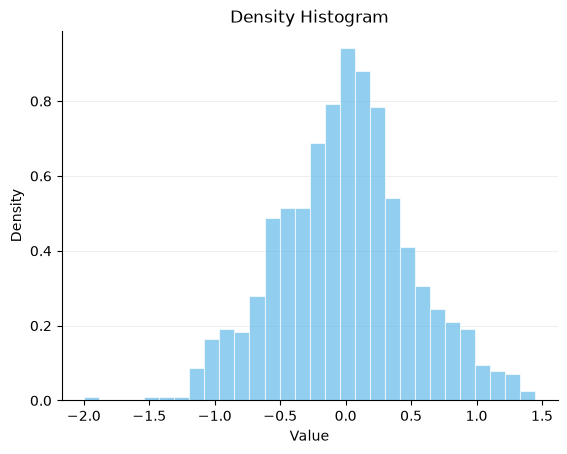

In [8]:
X[0.5].sim(1000).plot()

In [9]:
values = X[0.5].sim(1000)
values.mean(), values.var()

(0.010865399127596747, 0.22122952146300617)

Closer to an end there is less room to move, so the spread shrinks. At `t = 0.1` it is `0.1 * 0.9` = 0.09.

In [10]:
X[0.1].sim(1000).var()

0.09243151811473654

## The bridge only exists between its two ends

Unlike `BrownianMotion`, which runs forever, a bridge is defined only from time 0 to `end_time`. Asking for a time outside that stretch is an error rather than a meaningless number, and the message tells you the stretch it does cover.

In [11]:
try:
    X.draw()(1.5)
except KeyError as error:
    print(error)

'Gaussian process is not defined at time 1.5. Time must be in the index set (TimeInterval(0, 1)).'
